In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings('ignore')

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans,DBSCAN
x,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)

In [3]:
sc=StandardScaler()
xs=sc.fit_transform(x)

In [5]:
df=pd.DataFrame(x,columns=['co1','co2'])
inertia=[]
k_range=range(1,10)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(xs)
    inertia.append(kmeans.inertia_)

In [6]:
inertia

[1000.0000000000002,
 297.89541410517234,
 11.575484723104983,
 9.752067977356848,
 8.257175272446283,
 6.917577320416797,
 6.334755391595287,
 5.704177177901432,
 5.060234133532079]

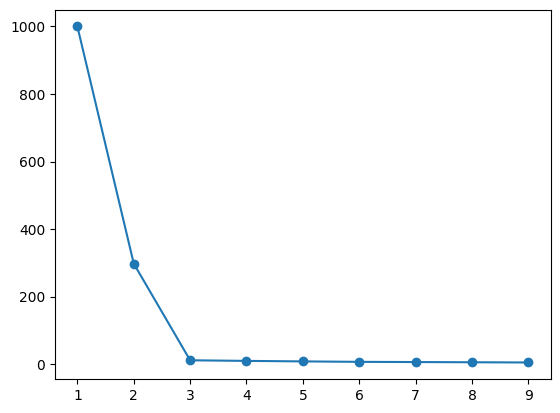

In [7]:
graph=plt.plot(k_range,inertia,marker='o')

In [8]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [ ]:
df.reset_index(drop=True,inplace=True)
df

AttributeError: 'DataFrame' object has no attribute 'drop_index'

In [ ]:
cluster_labels=kmeans.fit_predict(xs)

In [ ]:
df['cluster']=cluster_labels

In [ ]:
df

,co1,co2,cluster
0,-6.190063,-7.302015,1
1,3.021747,1.940593,0
2,5.953761,1.488191,0
3,-2.744463,8.136177,2
4,5.360607,1.728324,0
...,...,...,...
495,-6.040014,-6.325329,1
496,-2.555459,9.218977,2
497,4.438408,2.974583,0
498,-7.193261,-6.250704,1


<Axes: xlabel='co1', ylabel='co2'>

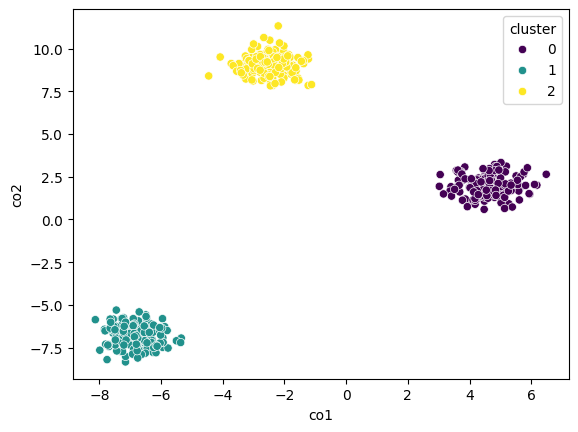

In [ ]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['cluster'],
                palette='viridis')

In [13]:
from sklearn.datasets import make_moons
x,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)
df=pd.DataFrame(x,columns=['co1','co2'])
sc=StandardScaler()
xs=sc.fit_transform(x)


In [15]:
kmeans=KMeans(n_clusters=2,random_state=42)
cluster_labels=kmeans.fit_predict(xs)
df['cluster']=cluster_labels

<Axes: xlabel='co1', ylabel='co2'>

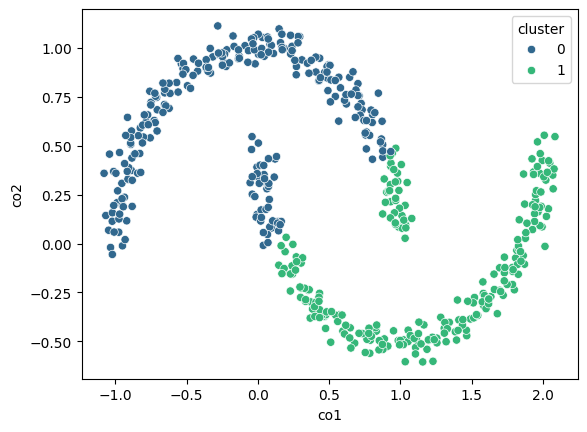

In [16]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['cluster'],
                palette='viridis')

In [17]:
dbsc=DBSCAN(eps=0.3,min_samples=5)
dblab=dbsc.fit_predict(xs)

In [18]:
df['lable']=dblab

In [19]:
df

,co1,co2,cluster,lable
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1
...,...,...,...,...
495,0.239754,0.985462,0,1
496,0.072145,0.184834,0,0
497,0.590273,-0.365577,1,0
498,1.619465,-0.283658,1,0


<Axes: xlabel='co1', ylabel='co2'>

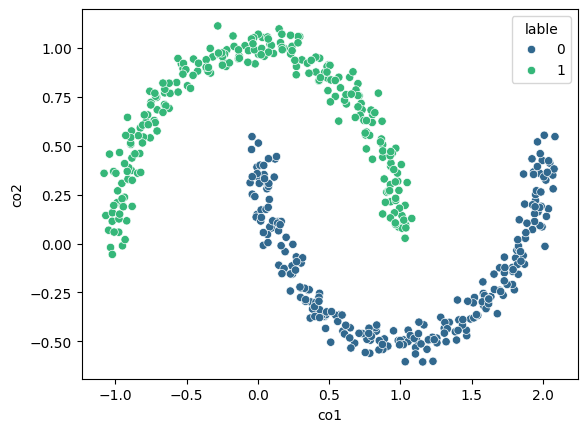

In [21]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['lable'],
                palette='viridis')

In [23]:
from sklearn.decomposition import PCA

In [26]:
x,y_true=make_blobs(n_samples=500,centers=3,cluster_std=1.5,n_features=5,random_state=42)
xs=sc.fit_transform(x)

In [30]:
pca=PCA(n_components=2)
afterpca=pca.fit_transform(xs)

In [33]:
df=pd.DataFrame(afterpca,columns=['co1','co2'])
df['pclab']=y_true

<Axes: xlabel='co1', ylabel='co2'>

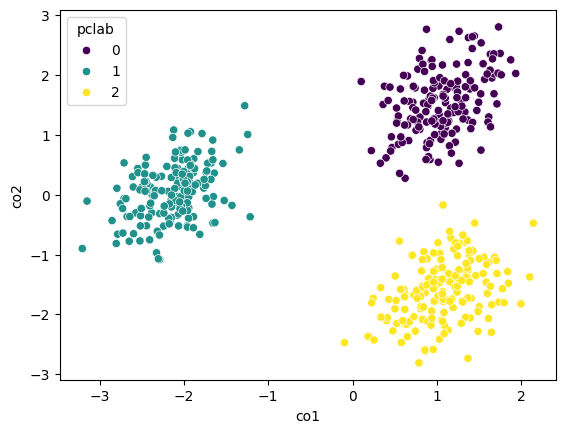

In [34]:
sns.scatterplot(x=df['co1'],
                y=df['co2'],
                hue=df['pclab'],
                palette='viridis')